# Chapter 13: Time Series Forecasting

**Book:** [Deep Learning with Python, Third Edition](https://deeplearningwithpython.io/chapters/chapter13_timeseries-forecasting/)

---

## Learning Goals
By the end of this notebook you will be able to:
1. Load and explore a real-world weather time series dataset
2. Normalize data correctly (using **only** training statistics)
3. Use `keras.utils.timeseries_dataset_from_array` to build sliding-window datasets
4. Evaluate a **common-sense baseline** before touching any neural network
5. Build and compare four model families: Dense, 1D-CNN, LSTM, GRU
6. Apply recurrent dropout and stacking to combat overfitting
7. Understand when Bidirectional RNNs help — and when they do not

---
## 1. The Jena Climate Dataset

We will use the **Jena Climate** dataset recorded at the Max Planck Institute for Biogeochemistry.
It contains 14 atmospheric measurements (temperature, pressure, humidity, wind speed, etc.)
sampled **every 10 minutes** from January 2009 to December 2016 — roughly 420 000 rows.

**Our forecasting task:** given the last 5 days of measurements, predict the temperature **24 hours into the future**.

### 1.1 Download & Inspect

Download the dataset from the Keras S3 bucket and unzip it.
After running this cell you will have 'jena_climate_2009_2016.csv'
in your working directory.

In [ ]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-03-08 21:50:27--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.191.111, 52.217.102.246, 3.5.12.219, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.191.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip.1’

jena_climate_2009_2 100%[===================>]  12.94M  19.0MB/s    in 0.7s    

2026-03-08 21:50:28 (19.0 MB/s) - ‘jena_climate_2009_2016.csv.zip.1’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
replace jena_climate_2009_2016.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: jena_climate_2009_2016.csv  
replace __MACOSX/._jena_climate_2009_2016.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


Read the CSV manually (no pandas) so we see exactly what's inside.

header  -> list of column names (Date Time, p (mbar), T (degC), ...)
lines   -> one string per data row (the header row is removed)

Printing the header tells us the column order — important later
when we index into the data array.

In [ ]:
import os

fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")       # one element per row
header = lines[0].split(",")   # column names from the first row
lines = lines[1:]              # drop the header row from the data

print(header)      # shows the 14 sensor column names
print(len(lines))  # total number of timesteps

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


Convert the raw text into NumPy arrays for efficient computation.

temperature  -> 1-D array holding only the temperature column (col 1
                after dropping the date-time string in col 0).
                This is our TARGET / label for prediction.

raw_data     -> 2-D array (n_timesteps × 14 features).
                This is our INPUT / feature matrix.

WHY separate temperature?  Because the target (what we predict) is
always the temperature 24 h ahead, but we need it on its own to
build the sliding-window target vector later.

In [ ]:
import numpy as np

temperature = np.zeros((len(lines),))                     # shape: (N,)
raw_data = np.zeros((len(lines), len(header) - 1))        # shape: (N, 14)

for i, line in enumerate(lines):
    # Skip column 0 (the date-time string); parse everything else as float
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]   # index 1 = T (degC) column
    raw_data[i, :] = values[:]   # all 14 sensor readings

### 1.2 Visualise the Temperature Signal

Plot the FULL temperature time series (all ~420 000 timesteps).
You should clearly see the annual seasonal cycle (hot summers,
cold winters). This macro-structure is something a good model
should learn to exploit.

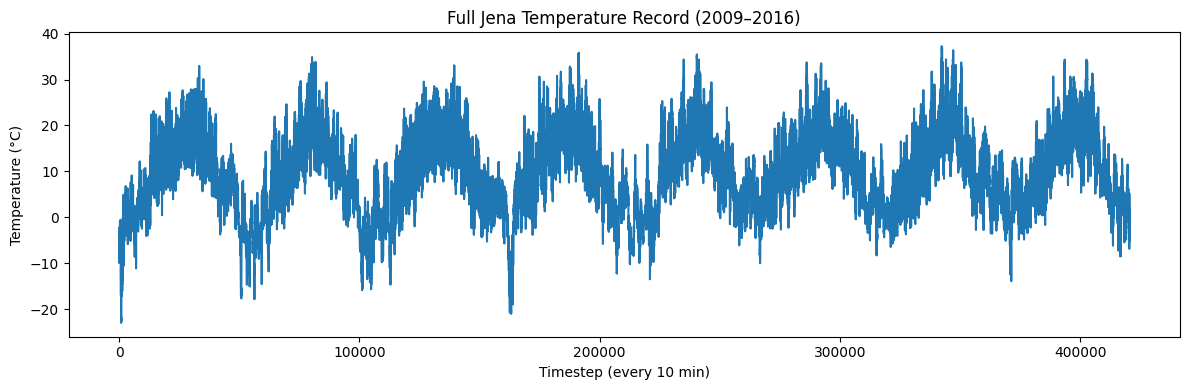

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(range(len(temperature)), temperature)
plt.xlabel("Timestep (every 10 min)")
plt.ylabel("Temperature (°C)")
plt.title("Full Jena Temperature Record (2009–2016)")
plt.tight_layout()
plt.show()

Zoom in on the FIRST 10 DAYS (1440 timesteps × 10 min = 10 days).

Why 1440?  1 day = 24 h × 60 min / 10 min = 144 timesteps.
           10 days = 1440 timesteps.

At this scale you can see the DAILY cycle — temperatures tend to
peak in the afternoon and dip before dawn. This daily periodicity
is the short-range pattern our models must capture.

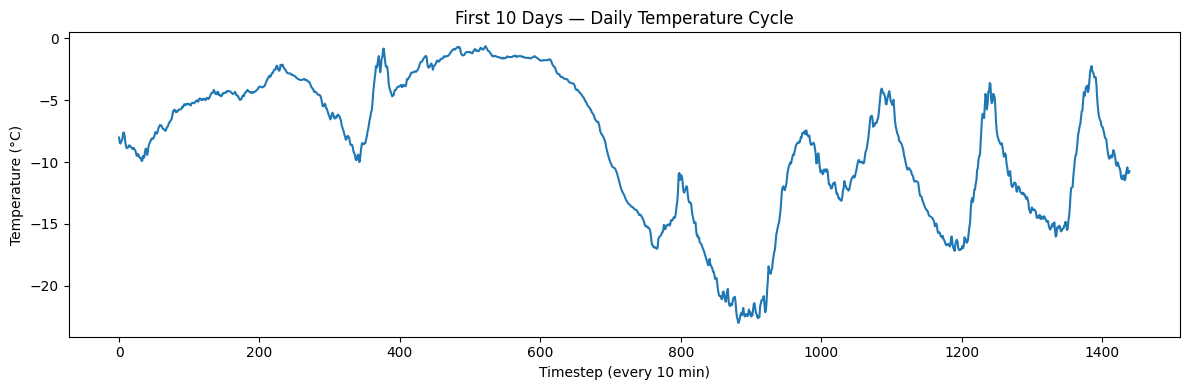

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(range(1440), temperature[:1440])
plt.xlabel("Timestep (every 10 min)")
plt.ylabel("Temperature (°C)")
plt.title("First 10 Days — Daily Temperature Cycle")
plt.tight_layout()
plt.show()

### 1.3 Train / Validation / Test Split

Split the data CHRONOLOGICALLY (never shuffle time series!):
  - Train  : first 50 % of timesteps  (~2009–2012)
  - Val    : next  25 %               (~2013–2014)
  - Test   : final 25 %               (~2015–2016)



In [ ]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples   = int(0.25 * len(raw_data))
num_test_samples  = len(raw_data) - num_train_samples - num_val_samples

print("num_train_samples:", num_train_samples)
print("num_val_samples:  ", num_val_samples)
print("num_test_samples: ", num_test_samples)

num_train_samples: 210225
num_val_samples:   105112
num_test_samples:  105114


---
## 2. Data Preparation

### 2.1 Normalisation (Z-score standardisation)

Standardise every feature to zero mean and unit variance.

CRITICAL: compute mean and std from the TRAINING SET ONLY.
Then apply those same constants to val and test sets.

WHY?  In a real deployment you would not have access to future data
when fitting the scaler. Using val/test statistics to normalise
would constitute data leakage — the model indirectly "sees" future
information during training.

After this cell raw_data is modified IN-PLACE:
  raw_data[i, j]  ←  (raw_data[i, j] − mean[j]) / std[j]

In [ ]:
mean = raw_data[:num_train_samples].mean(axis=0)   # shape: (14,) — one mean per feature
raw_data -= mean                                   # subtract training mean from ALL rows
std  = raw_data[:num_train_samples].std(axis=0)    # shape: (14,) — one std per feature
raw_data /= std                                    # divide ALL rows by training std

### 2.2 Building Sliding-Window Datasets with `timeseries_dataset_from_array`

A time series model needs **(input window, target)** pairs.
Instead of writing the sliding window loop ourselves, Keras provides
`keras.utils.timeseries_dataset_from_array` which does exactly this efficiently.

Let's understand the API with a tiny toy example first.

TOY EXAMPLE — understand timeseries_dataset_from_array

int_sequence = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

We want: given 3 consecutive values, predict the value 3 steps ahead.
  Input window  = int_sequence[:-3]  → [0..6]   (stop 3 before end)
  Targets       = int_sequence[3:]   → [3..9]   (start 3 from beginning)

The function creates pairs:
  [0,1,2] → 3
  [1,2,3] → 4
  [2,3,4] → 5   ... and so on

batch_size=2 means it returns 2 pairs at a time (as tensors).

In [ ]:
import numpy as np
import keras

int_sequence = np.arange(10)   # [0, 1, 2, ..., 9]

dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],    # input data  (drop last 3 so windows fit)
    targets=int_sequence[3:],  # target data (offset by 3 = prediction horizon)
    sequence_length=3,         # each input window contains 3 timesteps
    batch_size=2,              # yield 2 samples per batch
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], "→", int(targets[i]))

[0, 1, 2] → 3
[1, 2, 3] → 4
[2, 3, 4] → 5
[3, 4, 5] → 6
[4, 5, 6] → 7


REAL DATASET PARAMETERS — translate the problem statement into numbers:

sampling_rate = 6
  The raw data is sampled every 10 min. We want one observation per
  hour → keep every 6th row (6 × 10 min = 60 min = 1 sample/hour).

sequence_length = 120
  We look back 120 hourly observations = 5 days of history.

delay = sampling_rate × (sequence_length + 24 − 1)
  This is the total offset between the START of the input window
  and its corresponding target. We want the target to be 24 hours
  AFTER the END of the window, which requires this formula.

batch_size = 256
  Number of (window, target) pairs yielded per training step.
  Larger batches → more stable gradients but more GPU memory.

In [ ]:
sampling_rate   = 6                                          # 1 observation per hour
sequence_length = 120                                        # look back 5 days
delay = sampling_rate * (sequence_length + 24 - 1)          # target is 24 h after window end
batch_size      = 256

# -------------------------------------------------------------------
# Build three separate tf.data.Dataset objects.
# start_index / end_index carve out non-overlapping time ranges so
# no data point appears in two splits.
#
# shuffle=True  for train  → randomise window order (breaks serial correlation)
#               False (default) for val/test → evaluate in time order
# -------------------------------------------------------------------
train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],          # input features: exclude the last `delay` rows
    targets=temperature[delay:],# targets: temperature `delay` steps ahead
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,               # shuffle order of windows during training
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

Sanity check: inspect one batch to confirm shapes.

Expected:
  samples shape: (256, 120, 14)  — batch × timesteps × features
  targets shape: (256,)          — one temperature value per sample

In [ ]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)   # (batch_size, sequence_length, num_features)
    print("targets shape:", targets.shape)   # (batch_size,)
    break  # we only need to inspect the first batch

samples shape: (256, 120, 14)
targets shape: (256,)


---
## 3. Common-Sense Baseline (No Machine Learning)

Before training any neural network, always ask: **what does a dumb heuristic achieve?**

Here our naive prediction is: *"the temperature 24 h from now will be the same as it is right now."*
This exploits the daily periodicity we observed in the plot.
Any model we build must **beat this baseline** to be worth deploying.

We measure error using **Mean Absolute Error (MAE)** in degrees Celsius — easy to interpret.

Naive baseline: predict that tomorrow's temperature equals today's.

samples[:, -1, 1]  → the LAST timestep (index -1) in the window,
                      feature index 1 = temperature column.

Because raw_data was normalised, we must UN-normalise the prediction
back to °C before comparing with the raw temperature targets:
  pred_celsius = normalised_value × std[1] + mean[1]

std and mean were computed over the training set (cell above).

In [ ]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen  = 0
    for samples, targets in dataset:
        # Un-normalise: undo the Z-score transform on the temperature feature
        preds = samples[:, -1, 1] * std[1] + mean[1]   # shape: (batch_size,)
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen  += samples.shape[0]
    return total_abs_err / samples_seen   # average MAE in °C

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE:       {evaluate_naive_method(test_dataset):.2f}")

# Typical result: ~2.4 °C — our neural models should beat this!

Validation MAE: 2.44
Test MAE:       2.62


---
## 4. Model 1 — Dense (Fully Connected) Baseline

A Dense model treats the entire flattened input window as an unordered feature vector.
It has **no awareness of temporal order** — the sequence [Mon, Tue, Wed] looks the same
as [Wed, Mon, Tue] to a Dense layer.

We build it anyway as the simplest possible neural baseline.

Dense model architecture:

  Input(120, 14)          — sequence window of shape (timesteps, features)
  → Flatten()             — collapse to a 1-D vector of size 120×14 = 1680
  → Dense(16, relu)       — learn 16 non-linear combinations of the flattened input
  → Dense(1)              — single output neuron = predicted temperature (regression)

Loss = MSE  (sensitive to large errors — common for regression)
Metric = MAE (interpretable in °C — matches the baseline we computed above)

ModelCheckpoint saves only the BEST validation epoch, protecting
against overfitting caused by training too long.

In [ ]:
import keras
from keras import layers

inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))  # (120, 14)
x       = layers.Flatten()(inputs)                                   # → (1680,)
x       = layers.Dense(16, activation="relu")(x)                     # → (16,)
outputs = layers.Dense(1)(x)                                         # → scalar
model   = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

# Reload the checkpoint saved at the best validation epoch
model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - loss: 12.4291 - mae: 2.7042 - val_loss: 10.0591 - val_mae: 2.4890
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 8.2689 - mae: 2.2607 - val_loss: 10.8216 - val_mae: 2.6074
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 7.5687 - mae: 2.1650 - val_loss: 10.7963 - val_mae: 2.6082
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 7.1045 - mae: 2.0983 - val_loss: 11.0516 - val_mae: 2.6467
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 6.8110 - mae: 2.0528 - val_loss: 11.1571 - val_mae: 2.6601
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - loss: 6.5631 - mae: 2.0158 - val_loss: 11.5482 - val_mae: 2.6936
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 6.3553 - mae: 1.9831 - val_loss: 11.4363 - val_mae: 2.6879
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 6.2549 - mae: 1.9653 - val_loss: 11.5986 - val_mae: 2.7145
Epoch 9/10
819/819 ━━━━━━━━━━━━

Learning curve: plot Training MAE vs Validation MAE per epoch.

WHAT TO LOOK FOR:
  - If val MAE >> train MAE after a few epochs → overfitting
  - If both curves are still falling at epoch 10 → underfitting
    (try more epochs or a larger model)
  - If val MAE plateaus while train MAE continues to drop → overfitting

This plot helps decide whether to change capacity, regularisation,
or number of training epochs.

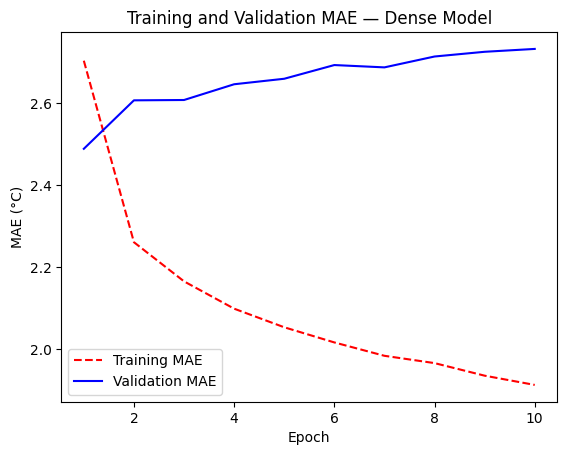

In [ ]:
import matplotlib.pyplot as plt

loss     = history.history["mae"]
val_loss = history.history["val_mae"]
epochs   = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss,     "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b",   label="Validation MAE")
plt.title("Training and Validation MAE — Dense Model")
plt.xlabel("Epoch")
plt.ylabel("MAE (°C)")
plt.legend()
plt.show()

Some of the validation losses are close to the no-learning baseline, but not reliably. This goes to show the merit of having this baseline in the first place: it turns out to be not easy to outperform. Your common sense contains a lot of valuable information to which a machine learning model doesn’t have access.

---
## 5. Model 2 — 1D Convolutional Neural Network

Conv1D applies learned filters that slide along the **time axis**.
Unlike Dense, it respects the temporal order of the window.


Think of each filter as a detector for a particular short-range pattern (e.g. a sharp morning warm-up).

1D-CNN architecture (hierarchical pattern extraction):

  Input(120, 14)
  → Conv1D(8 filters, kernel=24, relu)   — detect patterns spanning 24 h
  → MaxPooling1D(2)                      — halve the sequence length (downsample)
  → Conv1D(8 filters, kernel=12, relu)   — detect patterns spanning ~1 day
  → MaxPooling1D(2)                      — halve again
  → Conv1D(8 filters, kernel=6,  relu)   — detect shorter patterns
  → GlobalAveragePooling1D()             — collapse temporal axis → single vector
  → Dense(1)                             — final temperature prediction

WHY hierarchical kernel sizes?  Early layers detect fine-grained patterns
(hours), later layers detect coarser patterns (days) after pooling reduces
the resolution. This is analogous to how CNNs on images learn edges → shapes → objects.

GlobalAveragePooling1D is preferred over Flatten here:
  it averages across remaining timesteps instead of concatenating them,
  which reduces the parameter count and acts as a mild regulariser.

In [ ]:
inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x       = layers.Conv1D(8, 24, activation="relu")(inputs)  # kernel spans 24 hourly steps
x       = layers.MaxPooling1D(2)(x)                         # halve sequence length
x       = layers.Conv1D(8, 12, activation="relu")(x)       # kernel spans ~12 steps
x       = layers.MaxPooling1D(2)(x)                         # halve again
x       = layers.Conv1D(8, 6,  activation="relu")(x)       # kernel spans ~6 steps
x       = layers.GlobalAveragePooling1D()(x)               # aggregate over time
outputs = layers.Dense(1)(x)
model   = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - loss: 24.5980 - mae: 3.8114 - val_loss: 14.0754 - val_mae: 2.9697
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 78s 52ms/step - loss: 14.7999 - mae: 3.0322 - val_loss: 13.9232 - val_mae: 2.9412
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 13.1698 - mae: 2.8670 - val_loss: 13.3989 - val_mae: 2.8863
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 12.3745 - mae: 2.7852 - val_loss: 13.4749 - val_mae: 2.8926
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 11.7574 - mae: 2.7193 - val_loss: 13.9140 - val_mae: 2.9360
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 11.3722 - mae: 2.6728 - val_loss: 14.1439 - val_mae: 2.9773
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - loss: 11.0064 - mae: 2.6284 - val_loss: 13.9185 - val_mae: 2.9459
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 10.8424 - mae: 2.6091 - val_loss: 14.1751 - val_mae: 2.9832
Epoch 9/10
819/819 ━━━━━

First, weather data doesn’t quite respect the translation invariance assumption. While the data does feature daily cycles, data from a morning follows different properties than data from an evening or from the middle of the night. Weather data is only translation-invariant for a very specific timescale.
Second, order in our data matters — a lot. The recent past is far more informative for predicting the next day’s temperature than data from five days ago. A 1D ConvNet is not able to make use of this fact. In particular, our max pooling and global average pooling layers are largely destroying order information.

---
## 6. Recurrent Neural Networks (RNNs)

### 6.1 How RNNs Work — From Scratch

An RNN processes a sequence **one timestep at a time**, maintaining a hidden **state vector**
that acts as a compressed memory of everything seen so far.

At each step:
```
state_t  =  tanh( W × input_t  +  U × state_{t-1}  +  b )
```
- `W` learns how to incorporate the current input
- `U` learns how to carry information forward from the previous state
- `b` is a bias term

The same weights `(W, U, b)` are **shared across all timesteps** — that is what makes an RNN efficient.

Manual implementation of a simple RNN forward pass using NumPy.
This is NOT used for training — it is a teaching demonstration to
show exactly what happens inside a recurrent layer.

Dimensions:
  timesteps       = 100  — length of the input sequence
  input_features  = 32   — dimensionality of each input vector x_t
  output_features = 64   — dimensionality of the hidden state

After the loop, final_output_sequence has shape (100 × 64 = 6400,)
which is all hidden states concatenated (equivalent to return_sequences=True).

In [ ]:
import numpy as np

timesteps       = 100
input_features  = 32
output_features = 64

inputs  = np.random.random((timesteps, input_features))    # dummy input sequence
state_t = np.zeros((output_features,))                     # initial hidden state = 0

# Learnable weight matrices (randomly initialised here for illustration)
W = np.random.random((output_features, input_features))    # input → state transformation
U = np.random.random((output_features, output_features))   # state → state transformation
b = np.random.random((output_features,))                   # bias

successive_outputs = []
for input_t in inputs:                                    # iterate over timesteps
    # Core RNN equation: mix current input with previous state
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)                   # record this timestep's output
    state_t = output_t                                    # pass state forward

# Stack all hidden states into one array
final_output_sequence = np.concatenate(successive_outputs, axis=0)
print("Final output sequence shape:", final_output_sequence.shape)

Final output sequence shape: (6400,)


### 6.2 Keras RNN Layers — `SimpleRNN`, `return_sequences`

Minimal SimpleRNN: variable-length input (None means "any length").
output shape → (batch_size, 16)  — only the FINAL hidden state.
Use this when you just need one summary vector for the whole sequence.

In [ ]:
num_features = 14
inputs  = keras.Input(shape=(None, num_features))   # None = variable sequence length
outputs = layers.SimpleRNN(16)(inputs)

return_sequences=False  (default)
Output: only the last hidden state → shape (batch_size, 16)

Use this when the next layer is Dense (needs a single vector).

In [ ]:
num_features = 14
steps   = 120
inputs  = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)  # → (batch, 16)
print(outputs.shape)

(None, 16)


return_sequences=True
Output: hidden state AT EVERY timestep → shape (batch_size, steps, 16)

Use this when STACKING recurrent layers — each layer needs a full
sequence as input, not just a summary vector.

In [ ]:
num_features = 14
steps   = 120
inputs  = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)   # → (batch, 120, 16)
print(outputs.shape)

(None, 120, 16)


STACKED RNN example (3 layers):
  - First two layers: return_sequences=True  → pass full sequence to next layer
  - Last layer:       return_sequences=False → output a single summary vector

Deeper stacks can model more complex temporal abstractions, at the cost
of more parameters and slower training. Always add dropout when stacking.

In [ ]:
inputs  = keras.Input(shape=(steps, num_features))
x       = layers.SimpleRNN(16, return_sequences=True)(inputs)   # layer 1
x       = layers.SimpleRNN(16, return_sequences=True)(x)        # layer 2
outputs = layers.SimpleRNN(16)(x)                               # layer 3: final state only

---
## 7. Model 3 — LSTM (Long Short-Term Memory)

**The vanishing gradient problem**: In a plain RNN, gradients shrink as they propagate
backward through many timesteps, making it impossible to learn long-range dependencies.

**LSTM** solves this with a dedicated **cell state** — a "conveyor belt" that carries
information unchanged across many steps unless gating mechanisms decide to update or forget.
The three gates (forget, input, output) are all learned from data.

In practice: prefer LSTM over SimpleRNN for sequences longer than ~20 steps.

Minimal LSTM model for temperature forecasting:

  Input(120, 14) → LSTM(16) → Dense(1)

LSTM(16): 16 hidden units. Despite being simple, LSTM handles long
sequences far better than SimpleRNN thanks to its cell state.

Compare this Test MAE to the Dense and 1D-CNN models above.

In [ ]:
inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x       = layers.LSTM(16)(inputs)   # LSTM automatically uses cell state gating
outputs = layers.Dense(1)(x)
model   = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - loss: 44.7566 - mae: 4.9332 - val_loss: 17.5768 - val_mae: 3.1237
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 14.3748 - mae: 2.8818 - val_loss: 11.1046 - val_mae: 2.5386
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 11.1386 - mae: 2.5831 - val_loss: 10.2428 - val_mae: 2.4620
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - loss: 10.2401 - mae: 2.4857 - val_loss: 9.8472 - val_mae: 2.4221
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 9.3129 - mae: 2.3792 - val_loss: 9.7020 - val_mae: 2.4104
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 8.9312 - mae: 2.3313 - val_loss: 9.6998 - val_mae: 2.4156
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 8.5721 - mae: 2.2874 - val_loss: 9.7385 - val_mae: 2.4208
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 8.3194 - mae: 2.2556 - val_loss: 9.6667 - val_mae: 2.4145
Epoch 9/10
819/819 ━━━━━━━━━━━━━━

---
## 8. Fighting Overfitting in RNNs

### 8.1 Recurrent Dropout

Standard dropout applied to RNN outputs does not work well because it disrupts the
signal along the time axis. The correct approach is **recurrent dropout**:
the same dropout mask is applied consistently at every timestep within a sequence.

Two types available in Keras LSTM:
- `dropout`:            applied to the **input** connections
- `recurrent_dropout`:  applied to the **recurrent** (state-to-state) connections

LSTM with dropout regularisation:

  recurrent_dropout=0.25  → drop 25 % of the recurrent connections
                             at each training step (same mask per sequence)
  Dropout(0.5)            → standard dropout on the LSTM's output vector
                             before the final Dense layer

We train for 50 epochs (more capacity to overfit → regularisation matters more).
ModelCheckpoint still saves only the best val epoch.

IMPORTANT: recurrent dropout disables CUDA-optimised kernels, so training
will be slower. This is a known trade-off.

In [ ]:
inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x       = layers.LSTM(32, recurrent_dropout=0.25)(inputs)  # regularise recurrent connections
x       = layers.Dropout(0.5)(x)                           # regularise LSTM output
outputs = layers.Dense(1)(x)
model   = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - loss: 34.8325 - mae: 4.3453 - val_loss: 11.3654 - val_mae: 2.5761
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 16.3801 - mae: 3.1407 - val_loss: 9.6120 - val_mae: 2.3937
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 15.0895 - mae: 3.0168 - val_loss: 9.1450 - val_mae: 2.3407
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - loss: 14.3737 - mae: 2.9442 - val_loss: 8.9655 - val_mae: 2.3225
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 13.9199 - mae: 2.8957 - val_loss: 8.8668 - val_mae: 2.3115
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 13.5389 - mae: 2.8550 - val_loss: 8.8408 - val_mae: 2.3042
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 13.2389 - mae: 2.8259 - val_loss: 8.8306 - val_mae: 2.3005
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 12.8921 - mae: 2.7886 - val_loss: 8.9049 - val_mae: 2.3120
Epoch 9/50
819/819 ━━━━━━━━━━━━

---
## 9. Model 4 — Stacked GRU with Dropout

**GRU (Gated Recurrent Unit)** is a simplified LSTM with two gates instead of three.
It is slightly cheaper to compute while achieving similar performance.

**Stacking** adds depth: each GRU layer learns higher-level temporal abstractions
on top of the previous layer's output sequences.

Two-layer stacked GRU with recurrent dropout:

  GRU layer 1: return_sequences=True  → pass full sequence to next GRU
  GRU layer 2: return_sequences=False → produce final summary vector
  Dropout(0.5)                        → regularise before Dense

recurrent_dropout=0.5 is aggressive — justified because stacked RNNs
have more capacity and are more prone to overfitting.

After 50 epochs, we reload the best checkpoint and evaluate on the test set.
Compare this MAE against all previous models to see the progression.

In [ ]:
inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x       = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)  # GRU layer 1
x       = layers.GRU(32, recurrent_dropout=0.5)(x)                              # GRU layer 2
x       = layers.Dropout(0.5)(x)                                                # regularise output
outputs = layers.Dense(1)(x)
model   = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - loss: 26.7645 - mae: 3.8461 - val_loss: 10.3586 - val_mae: 2.4526
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 14.9943 - mae: 2.9933 - val_loss: 9.0019 - val_mae: 2.3135
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 14.0577 - mae: 2.9019 - val_loss: 8.6729 - val_mae: 2.2773
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 13.5556 - mae: 2.8520 - val_loss: 8.6040 - val_mae: 2.2711
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 13.0739 - mae: 2.8028 - val_loss: 8.4085 - val_mae: 2.2449
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 12.7677 - mae: 2.7690 - val_loss: 8.6555 - val_mae: 2.2845
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 12.4016 - mae: 2.7270 - val_loss: 8.5116 - val_mae: 2.2649
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 80s 60ms/step - loss: 12.0330 - mae: 2.6905 - val_loss: 8.4335 - val_mae: 2.2522
Epoch 9/50
819/819 ━━━━━━━━━━━━

---
## 10. Bidirectional RNNs

A **Bidirectional** RNN runs two copies of the recurrent layer:
- one processes the sequence **forward** (left → right)
- one processes it **backward** (right → left)

Their outputs are concatenated, giving the model access to both past and future context.

**When is it useful?**
- NLP tasks (sentiment, translation) where future words inform the meaning of current ones ✅
- Time series **forecasting** where the future is genuinely unknown ❌

For forecasting, Bidirectional RNNs typically do not help because the backward pass
processes data in reverse time order, which does not correspond to any real causal structure.

Bidirectional LSTM model:

  layers.Bidirectional(layers.LSTM(16))
  wraps the LSTM in a Bidirectional container that automatically:
    1. Runs LSTM forward  → produces a 16-D state vector
    2. Runs LSTM backward → produces another 16-D state vector
    3. Concatenates them  → yields a 32-D output vector

Expected result: comparable to or slightly WORSE than the simple LSTM
on this forecasting task, confirming that backward context does not
help when predicting future temperatures.

In [ ]:
inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x       = layers.Bidirectional(layers.LSTM(16))(inputs)  # forward + backward LSTM
outputs = layers.Dense(1)(x)
model   = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - loss: 31.7490 - mae: 4.0757 - val_loss: 12.2686 - val_mae: 2.7033
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 11.3626 - mae: 2.6387 - val_loss: 10.2860 - val_mae: 2.4854
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 9.8082 - mae: 2.4410 - val_loss: 9.9396 - val_mae: 2.4583
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 8.9299 - mae: 2.3242 - val_loss: 9.9663 - val_mae: 2.4402
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 8.4772 - mae: 2.2630 - val_loss: 9.7680 - val_mae: 2.4137
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 7.9037 - mae: 2.1836 - val_loss: 10.1124 - val_mae: 2.4566
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - loss: 7.4878 - mae: 2.1287 - val_loss: 10.4251 - val_mae: 2.4981
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 7.2216 - mae: 2.0896 - val_loss: 10.7062 - val_mae: 2.5355
Epoch 9/10
819/819 ━━━━━━━━━━━━━━

---
## 11. Summary & Model Comparison

### Key Takeaways
1. **Always start with a naive baseline.** If your model cannot beat it, the model is wrong.
2. **Normalise using training statistics only.** Never touch val/test statistics during preprocessing.
3. **Time series splits must be chronological.** Random splits cause data leakage.
4. **SimpleRNN < LSTM ≈ GRU** for sequences with long-range dependencies.
5. **Recurrent dropout** (not regular dropout) is the correct regulariser for RNNs.
6. **Bidirectional RNNs** shine in NLP but generally do not help in forecasting.
7. **Stacking** adds capacity but requires stronger regularisation.